# DGC / Waddington-OT TF-control analysis (self-contained)

Depends only on the `dgc_pipeline/` package + numpy/scipy/pandas/anndata.

Pipeline:
1.  Backend + data load
2.  Trajectories (Option A: load cache / Option B: build from transport maps + save)
3.  `mouse_panel_symbols` — gene-name list every downstream piece lives in
4.  Operators: 12h M and the interleaved 24h M (with the M_24 vs M_12^2 check)
5.  Target (iPSC biological)
6.  States in CENTERED coordinates (M was fit on centered dynamics)
7.  Binding-B
8.  `b_OSKM_effect` ground truth (inferred from the known Dox input in Schiebinger)
9.  Norman-B (CRISPRa Perturb-seq deconvolution against the 24h operator)
10. Head-to-head: binding-B-OSKM vs Norman-B-OSKM, both against `b_OSKM_effect`
11. Scoring + best-day control
12. Importance (LOO + mass)
13. Diagnostics (fusion vs averaging, forcing SVD, geometry)

**Frame convention:** M is fit on mean-centered dynamics; the free evolution of a raw state is `M^N(x_init,raw − xbar) + xbar`, so the gap is `(x_target − xbar) − M^N (x_init − xbar)` = the centered residual. Score in centered coordinates throughout.

## 0. Setup

In [1]:
import sys, os
import numpy as np
sys.path.insert(0, os.path.abspath('.'))   # folder containing dgc_pipeline/

from dgc_pipeline import (Backend, OperatorSequence, FusedOperatorBuilder,
                          DGCOperatorBuilder, TargetBuilder, TrajectoryBuilder,
                          BOnlyScorer, DynamicsScorer, ControlBestDayScorer,
                          InterleavedFusion, NormanBBuilder,
                          make_response_sum, tikhonov_deconvolve,
                          fusion_vs_averaging, forcing_svd, forcing_geometry)
from dgc_pipeline import io as dio

DATA = dict(
    expr      = 'data/ExprMatrix.var.genes.h5ad',
    cell_days = 'data/cell_days.txt',
    cell_sets = 'major_cell_sets.gmt',
    tmap_dir  = 'tmaps',
    b_cache   = 'b_cache/B_binding_07a8161f4b109116.npz',
    traj_cache= 'traj_cache.npz',
    norman    = 'data/fibroblast_CRISPRa_custom_mean.h5ad',   # or _mean_pop.h5ad
    norman_out= 'b_norman.npz',
)
USE_GPU = True
IPSC_SET = 'iPSC'

## 1. Backend

In [2]:
be = (Backend.gpu(require=True) if USE_GPU else Backend.cpu()).activate()
print('on_gpu:', be.on_gpu)

  GPU backend: NVIDIA GeForce RTX 5060 Laptop GPU (compute 12.0), kernel test OK
on_gpu: True


## 2. Load expression, cell days, transport maps

In [3]:
A = dio.load_expression(DATA['expr'])
genes = np.asarray(A.var_names)
cell_days = dio.load_cell_days(DATA['cell_days'])
tmap_chain = dio.discover_tmaps(DATA['tmap_dir'])
print(f'genes={len(genes)}  tmaps={len(tmap_chain)}  cells-with-days={len(cell_days)}')

  251203 cells x 1479 genes
genes=1479  tmaps=38  cells-with-days=236285


## 3. Trajectories — run EITHER 3A (load) OR 3B (build + save)

### 3A. Load cached

In [4]:
if os.path.exists(DATA['traj_cache']):
    Z = TrajectoryBuilder.load(DATA['traj_cache'])
    traj_c, xbar, panel = Z['traj_c'], Z['xbar'], Z['panel']
    seed_ids = list(Z['seed_ids']) if 'seed_ids' in Z else None
    fate     = Z['fate'] if 'fate' in Z else None
    L, K, G = traj_c.shape; n_steps = K - 1
    print(f'loaded: L={L} K={K} G={G}; panel={len(panel)}')
else:
    print('no cache yet -- run 3B')

loaded: L=4556 K=39 G=1479; panel=1479


### 3B. Build from transport maps + save (Option B)

In [5]:
# tbuild = TrajectoryBuilder(tmap_chain, A, genes)
# traj, seed_ids = tbuild.build()
# traj_c, xbar   = TrajectoryBuilder.center(traj)
# panel          = TrajectoryBuilder.panel(traj, n_top=None)
# tb_t = TargetBuilder(A, genes, DATA['cell_sets'], ipsc_key_substr=IPSC_SET)
# ipsc_rows = tb_t._resolve_rows()
# ipsc_cell_ids = np.asarray(A.obs_names)[ipsc_rows] if len(ipsc_rows) else []
# fate = tbuild.seed_fate(seed_ids, ipsc_cell_ids) if len(ipsc_cell_ids) else None
# L, K, G = traj_c.shape; n_steps = K - 1
# TrajectoryBuilder.save(DATA['traj_cache'], traj_c, xbar, panel,
#                        seed_ids=seed_ids, fate=fate)
# print(f'built + saved: L={L} K={K} G={G}; panel={len(panel)}')

## 4. Mouse panel symbols
The gene-name list every downstream piece (orthology, binding-B, Norman-B, head-to-head) lives in.
It is just `genes[panel]`, defined here once so it can be referenced everywhere.

In [6]:
mouse_panel_symbols = np.asarray([str(g) for g in genes[panel]])
print(f'mouse_panel_symbols: {len(mouse_panel_symbols)} genes')
print(f'  first 10: {list(mouse_panel_symbols[:10])}')
for tf in ['Pou5f1','Sox2','Klf4','Myc','Nanog','Esrrb','Zfp42','Nr5a2']:
    print(f'  {tf}: {"YES" if tf in mouse_panel_symbols else "no"}')

mouse_panel_symbols: 1479 genes
  first 10: [np.str_('Fam150a'), np.str_('3110035E14Rik'), np.str_('Prex2'), np.str_('Sulf1'), np.str_('Pi15'), np.str_('Crispld1'), np.str_('Tfap2b'), np.str_('Khdc1c'), np.str_('Col9a1'), np.str_('Il1r2')]
  Pou5f1: no
  Sox2: YES
  Klf4: no
  Myc: YES
  Nanog: YES
  Esrrb: no
  Zfp42: no
  Nr5a2: no


## 5. Operators: 12h M_12, 24h M_24 (interleaved), and the consistency check
We fit BOTH a 12h-step operator (for fine-grained scoring) and a 24h-step operator (for deconvolution — `S_7` is much better-conditioned than `S_14`).

The PRIMARY consistency check the `InterleavedFusion` prints is `cos(D_24_fused, M_12² − I)`: the 24h fit and the squared 12h fit should agree if the dynamics are time-translation invariant. M1 vs M2 disagreement alone is NOT evidence against the model — period-2 effects can split them benignly.

In [54]:
fused_op, info = FusedOperatorBuilder(be).build(
    traj_c, ridge=0.0, eps_fuse=0.05, gene_panel=panel,
    pair_lineages=True, pair_seed=0,
    explained_variance_threshold=0.95,   # 80% energy threshold per pair
    n_steps_hint=n_steps)
    
print(f"\nrho(M_12)={info['rho']:.4f}  rank(D_12)={info['fused_rank']}")
dgc_ops, _ = DGCOperatorBuilder().build(traj_c[:, :, panel])
seq_dgc    = OperatorSequence(dgc_ops)
seq_fused  = OperatorSequence([fused_op])
from dgc_pipeline import recover_input_and_validate
health = recover_input_and_validate(
    fused_op.as_matrix(len(panel)), traj_c, panel=panel,
    xbar=xbar, heldout_frac=0.2, seed=0)

  lineage pairing: 4556 difference series from L=4556 lineages
  fused over 4556 lineages (ridge=0, adaptive (threshold=0.95)); per-lineage rank ~2; rank(D_fused)=1306 (G=1479)
  per-lineage rank distribution: min=1 5%=1 25%=2 median=2 75%=3 95%=4 max=5 mean=2.3
  rank histogram:
    r=  1:   616 ( 13.5%) ##########
    r=  2:  2345 ( 51.5%) ########################################
    r=  3:  1347 ( 29.6%) ######################
    r=  4:   244 (  5.4%) ####
    r=  5:     4 (  0.1%) 
  per-lineage DMD fit R^2: median=0.979 mean=0.975 [10th=0.956, 90th=0.991]
  per-COMPONENT propagator rho(I+A_l): median=0.489 mean=0.564 max=1.017 min=0.023; 216/4556 unstable (rho>1)
  S=sum P_l spectrum: min=0.00 max=1829.19 mean=7.79 | eps_fuse=0.05
  S-eig within 0.1 of integer: 0.46  (smeared)
  PROPAGATOR M=I+D spectrum: rho(M)=1.0106  (UNSTABLE -> powers explode)
    sigma_max(M)=3.6254  (non-normality gap sigma_max-rho = 2.6148; large => transient amplification)
    |eig(M)|: max=1.011 median=

--- Top 10 Eigenvalues of M_12 (by magnitude) ---
Rank |  Magnitude |       Real |  Imaginary
---------------------------------------------
   1 |     1.0000 |     1.0000 |     0.0000
   2 |     1.0000 |     1.0000 |     0.0000
   3 |     1.0000 |     1.0000 |    -0.0000
   4 |     1.0000 |     1.0000 |     0.0000
   5 |     1.0000 |     1.0000 |    -0.0000
   6 |     1.0000 |     1.0000 |     0.0000
   7 |     1.0000 |     1.0000 |    -0.0000
   8 |     1.0000 |     1.0000 |     0.0000
   9 |     1.0000 |     1.0000 |     0.0000
  10 |     1.0000 |     1.0000 |    -0.0000
  11 |     1.0000 |     1.0000 |     0.0000
  12 |     1.0000 |     1.0000 |    -0.0000
  13 |     1.0000 |     1.0000 |     0.0000
  14 |     1.0000 |     1.0000 |     0.0000
  15 |     1.0000 |     1.0000 |     0.0000
  16 |     1.0000 |     1.0000 |    -0.0000
  17 |     1.0000 |     1.0000 |     0.0000
  18 |     1.0000 |     1.0000 |     0.0000
  19 |     1.0000 |     1.0000 |    -0.0000
  20 |     1.0000 |     

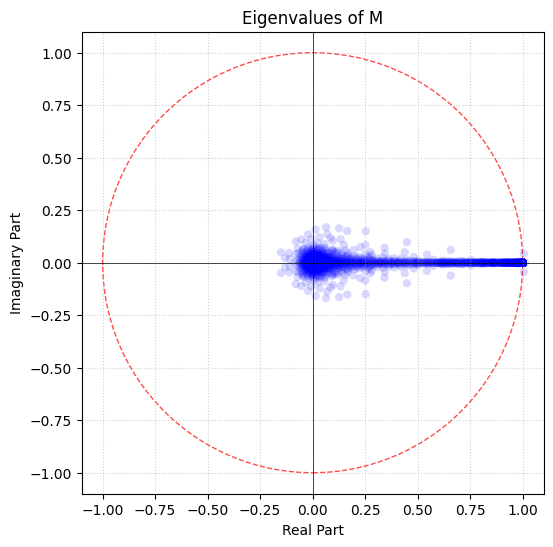

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Get the dense M12 matrix and compute all eigenvalues
M12 = fused_op.as_matrix(len(panel))
eigvals = np.linalg.eigvals(M12)

# 2. Sort eigenvalues by magnitude (absolute value) in descending order
sorted_indices = np.argsort(np.abs(eigvals))[::-1]
sorted_eigvals = eigvals[sorted_indices]

# 3. Print the Top 10 eigenvalues
print("--- Top 10 Eigenvalues of M_12 (by magnitude) ---")
print(f"{'Rank':>4} | {'Magnitude':>10} | {'Real':>10} | {'Imaginary':>10}")
print("-" * 45)
for i in range(30):
    val = sorted_eigvals[i+200]
    print(f"{i+1:>4} | {np.abs(val):>10.4f} | {np.real(val):>10.4f} | {np.imag(val):>10.4f}")

# 4. Plot the Top 50 eigenvalues in the complex plane
top_k = 10000
top_eigvals = sorted_eigvals[:top_k]

fig, ax = plt.subplots(figsize=(6, 6))

# Draw the unit circle for reference
unit_circle = plt.Circle((0, 0), 1.0, color='red', fill=False, linestyle='--', alpha=0.7, label='Unit Circle (|λ| = 1)')
ax.add_patch(unit_circle)

# UPDATED: edgecolors='none' removes the outlines, alpha controls the opacity
ax.scatter(np.real(top_eigvals), np.imag(top_eigvals), 
           color='blue', 
           alpha=0.15,       # Adjust this (0.0 to 1.0) to your preference
           edgecolors='none') 

# Formatting
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_aspect('equal', 'box')
ax.set_xlabel('Real Part')
ax.set_ylabel('Imaginary Part')
ax.set_title(f'Eigenvalues of M')

max_val = np.max(np.abs(top_eigvals))
limit = max(1.1, max_val + 0.05)
ax.set_xlim(-limit, limit)
ax.set_ylim(-limit, limit)

ax.grid(True, linestyle=':', alpha=0.6)
plt.show()

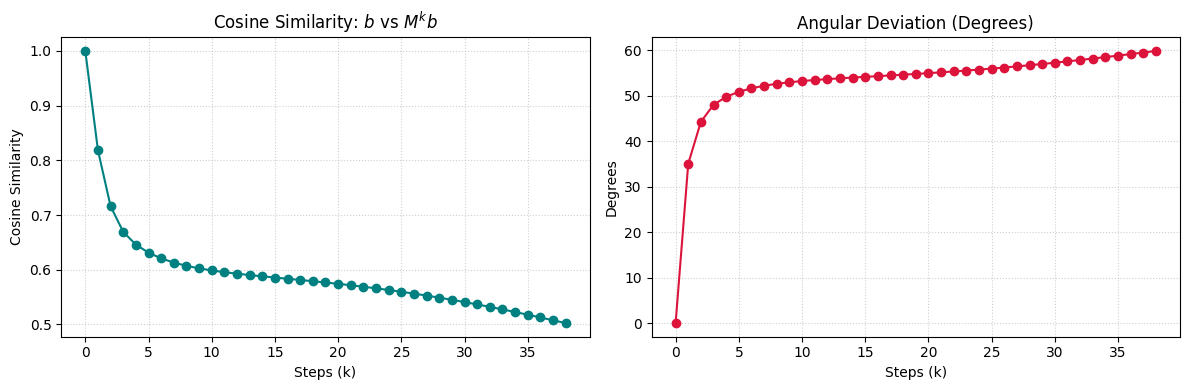

In [57]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Initialize
b_initial = b_OSKM_effect.copy()
b_current = b_OSKM_effect.copy()

cosines = [1.0]
angles_deg = [0.0]

# 2. Track the rotation of the vector at each step
for k in range(1, n_steps):
    b_current = M12 @ b_current
    
    # Compute cosine similarity
    cos_sim = np.dot(b_initial, b_current) / (np.linalg.norm(b_initial) * np.linalg.norm(b_current) + 1e-12)
    
    # Clip to avoid floating point errors before arccos
    cos_sim = np.clip(cos_sim, -1.0, 1.0)
    
    cosines.append(cos_sim)
    angles_deg.append(np.degrees(np.arccos(cos_sim)))

# 3. Plot the cascade geometry
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(n_steps), cosines, marker='o', color='teal')
ax1.set_title("Cosine Similarity: $b$ vs $M^k b$")
ax1.set_xlabel("Steps (k)")
ax1.set_ylabel("Cosine Similarity")
ax1.grid(True, linestyle=':', alpha=0.6)

ax2.plot(range(n_steps), angles_deg, marker='o', color='crimson')
ax2.set_title("Angular Deviation (Degrees)")
ax2.set_xlabel("Steps (k)")
ax2.set_ylabel("Degrees")
ax2.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [ ]:
# FIX this test. I want to test whether just using forcing fitted onto data can outperform our linear matrix model. 
import numpy as np

L, K_steps, G = traj_c.shape

# 1. The True Target: Empirical Change (Delta x) for all lineages
dx_true = traj_c[:, 1:, :] - traj_c[:, :-1, :]  # Shape: (4556, 38, 1479)

# 2. Build the User's Null Model (Time-Varying Global Average Forcing)
# Calculate b_t: the average empirical change across all lineages at each time step
b_t = dx_true.mean(axis=0)  # Shape: (38, 1479)

# The null model predicts every lineage simply shifts by the global average change b_t
dx_pred_null = np.broadcast_to(b_t, dx_true.shape)

# 3. Build the Full Model (Intrinsic Network + Constant OSKM Forcing)
# Since M x = (I + D) x = x + D x, the predicted change is D x + b
D12 = M12 - np.eye(G)
D12_T = D12.T
dx_pred_full = np.zeros_like(dx_true)

for k in range(K_steps - 1):
    dx_pred_full[:, k, :] = traj_c[:, k, :] @ D12_T + b_OSKM_effect

# 4. Calculate 1-Step R^2 on the Changes
global_dx_mean = np.mean(dx_true, axis=(0, 1), keepdims=True)
ss_tot_dx = np.sum((dx_true - global_dx_mean)**2)

ss_res_full_dx = np.sum((dx_true - dx_pred_full)**2)
ss_res_null_dx = np.sum((dx_true - dx_pred_null)**2)

r2_full_dx = 1.0 - (ss_res_full_dx / (ss_tot_dx + 1e-12))
r2_null_dx = 1.0 - (ss_res_null_dx / (ss_tot_dx + 1e-12))

print("--- 1-Step Ahead Predictive Power on Cell State Changes (Δx) ---")
print(f"Full Model (Constant M + Constant b):     {r2_full_dx:.4f}")
print(f"Null Model (Time-Varying Empirical b_t):  {r2_null_dx:.4f}")
print(f"Network Contribution (Cell-Specific Δx):  {(r2_full_dx - r2_null_dx):.4f}")

--- 1-Step Ahead Predictive Power on Cell State Changes (Δx) ---
Full Model (Constant M + Constant b):     -0.5001
Null Model (Time-Varying Empirical b_t):  0.7866
Network Contribution (Cell-Specific Δx):  -1.2867


## 5b. Operator health check
Full `recover_Bu_and_predict`-style reporting on the 12h operator:
- **[A]** held-out per-lineage R²(state) and R²(change)
- **[B]** mean-trajectory roll-forward R² (no Bu / constant Bu / time-varying Bu)
- **[C]** recovered `Bu_const` and residual scatter `||std||/||mean||`
- **[D]** cross-lineage spread `ratio(res/state)` — tight = real shared input
- **[E]** per-step Bu consistency table — watch the early steps for state-dependent B(x)

Run this once per operator fit; the numbers are what define the health of the run.

In [8]:
from dgc_pipeline import recover_input_and_validate
health = recover_input_and_validate(
    fused_op.as_matrix(len(panel)), traj_c, panel=panel,
    xbar=xbar, heldout_frac=0.2, seed=0)

  HEALTH CHECK on fitted operator (panel G=1479, L=4556 lineages)

  [A] R^2(M on pair differences) = +0.8167  (200 random pairs)

  [B] Per-lineage roll-forward R^2 (4556 lineages):
    constant Bu:        R^2 = +0.8720
    time-varying bu_k:  R^2 = +0.9989

  [C] Centered PCA on 173128 per-lineage b^l_k vectors:
    PC[1]  sv_norm=1.0000  explains 41.02%  cum=41.02%
    PC[2]  sv_norm=0.6230  explains 15.92%  cum=56.94%
    PC[3]  sv_norm=0.4882  explains  9.78%  cum=66.72%
    PC[4]  sv_norm=0.3853  explains  6.09%  cum=72.81%
    PC[5]  sv_norm=0.3465  explains  4.93%  cum=77.73%
    PC[6]  sv_norm=0.3017  explains  3.73%  cum=81.47%
    PC[7]  sv_norm=0.2759  explains  3.12%  cum=84.59%
    PC[8]  sv_norm=0.2689  explains  2.97%  cum=87.55%
    Top 4 cumulative: 72.8%   Top 8: 87.6%

  [D] ||Bu_const|| = 23.8190   residual scatter ||std||/||mean|| = 0.478

  [E] Cross-lineage spread on Bu_const direction:
    state std median  = 0.411
    resid std median  = 0.073
    ratio (res/s

## 6. Target — iPSC biological state (purity-gated)

In [15]:
days_arr = sorted(set(cell_days.values()))
tb = TargetBuilder(A, genes, f"data/{DATA['cell_sets']}", ipsc_key_substr=IPSC_SET,
                   cell_days=cell_days)
ipsc_full = tb.biological()
if ipsc_full is None:
    print('  biological() returned None; trying centroid()...')
    ipsc_full = tb.centroid()
if ipsc_full is None:
    print('  centroid() also None; using mean trajectory endpoint as fallback')
    ipsc_full = traj_c.mean(axis=0)[-1] + xbar
print(f'  target source: ||ipsc_full||={np.linalg.norm(ipsc_full):.1f}')

  iPSC-biological target: returning None (no iPSC cells resolved from cell-sets file 'data/major_cell_sets.gmt' under key '~iPSC'; check the file and final-day filter)
  biological() returned None; trying centroid()...
  centroid() also None; using mean trajectory endpoint as fallback
  target source: ||ipsc_full||=31.0


In [18]:
import numpy as np
from dgc_pipeline.io import load_gmt, ENDOGENOUS_PLURIPOTENCY

print("--- Bypassing TargetBuilder ---")

# 1. Load GMT directly in the notebook environment
sets = load_gmt(f"data/{DATA['cell_sets']}")
ipsc_ids = set(sets['IPS'])

# 2. Get exact row indices in A
obs = np.asarray(A.obs_names)
mask = np.array([c in ipsc_ids for c in obs])
rows = np.where(mask)[0]
print(f"iPSC cells found in matrix A: {rows.size}")

# 3. Extract the dense expression matrix for those cells
X_ipsc = A.X[rows, :]
if hasattr(X_ipsc, "toarray"):
    X_ipsc = X_ipsc.toarray()

# 4. Apply the Biological Purity Gate (Top 25% of endogenous markers)
gidx = {g: i for i, g in enumerate(genes)}
markers = [g for g in ENDOGENOUS_PLURIPOTENCY if g in gidx]
midx = [gidx[g] for g in markers]

Xm = X_ipsc[:, midx]
mu = Xm.mean(0, keepdims=True)
sd = Xm.std(0, keepdims=True) + 1e-8
purity = ((Xm - mu) / sd).mean(axis=1)

# Keep the purest cells
keep = purity >= np.quantile(purity, 0.75)
print(f"Cells passing endogenous purity gate: {keep.sum()}")

# 5. Lock in the target vector!
ipsc_full = X_ipsc[keep].mean(axis=0).ravel()
print(f"||ipsc_full|| = {np.linalg.norm(ipsc_full):.1f}")

--- Bypassing TargetBuilder ---
iPSC cells found in matrix A: 56597
Cells passing endogenous purity gate: 14152
||ipsc_full|| = 34.9


## 7. States (CENTERED — matches the operator frame)

In [19]:
x_init   = traj_c.mean(axis=0)[0, panel]
x_target = (ipsc_full - xbar)[panel]
print(f'||x_init||={np.linalg.norm(x_init):.1f}  ||x_target||={np.linalg.norm(x_target):.1f}')

||x_init||=24.1  ||x_target||=27.3


## 8. Binding-B (the existing DGC-style construction, under test)
Note: the cached B from the monolith may store TF names under key `'tfs'` rather than `'tf_names'`.
This cell tries both.

In [22]:
import os
import numpy as np
from dgc_pipeline.binding_B import build_B_binding
from dgc_pipeline.io import KNOWN_IPSC_TFS

# 1. Define paths to your genomic reference files 
# (Update these paths to point to where you stored the mm10/GSE99009 files)
REFGENE_PATH = "data/refGene.txt"
GSE_DIR      = "data/GSE99009/"
JASPAR_PATH  = "data/JASPAR2024_CORE_vertebrates_non-redundant_pfms_meme.txt" 
GENOME_PATH  = "data/mm10.fa"

# The exact cache path your notebook expects in Cell 8
B_CACHE_OUT  = "b_cache/B_binding_07a8161f4b109116.npz"

# Ensure the cache directory exists
os.makedirs(os.path.dirname(B_CACHE_OUT), exist_ok=True)

# 2. Define the candidate TFs to build columns for.
# We pool the 1479 mouse panel genes + the experimental OSKM/pluripotency list.
candidate_tfs = list(set(list(mouse_panel_symbols) + KNOWN_IPSC_TFS))

print(f"Starting binding-B build for {len(candidate_tfs)} candidate TFs...")

# 3. Build the matrix
# Note: If you don't have the 2.6GB mm10.fa file downloaded yet, 
# you can set jaspar_path=None and genome_path=None to skip the slow motif 
# scan and build a matrix containing ONLY the OSKM ChIP-seq data.
B_binding, tf_names_binding = build_B_binding(
    genes=mouse_panel_symbols,
    tf_list=candidate_tfs,
    refgene_path=REFGENE_PATH,
    gse_dir=GSE_DIR,
    jaspar_path=JASPAR_PATH,
    genome_path=GENOME_PATH,
    window=5000,
    motif_threshold=8.0,
    restrict_tfs=candidate_tfs, 
    include_body=False,
    verbose=True
)

# 4. Cache it exactly how the notebook expects it
np.savez(
    B_CACHE_OUT, 
    B=B_binding, 
    tf_names=np.asarray(tf_names_binding, dtype=object),
    gene_names=np.asarray(mouse_panel_symbols, dtype=object)
)

print(f"\nSuccessfully built and cached B_binding to: {B_CACHE_OUT}")
print(f"Matrix shape: {B_binding.shape}")

Starting binding-B build for 1492 candidate TFs...
  TSS: 26202 gene symbols from refGene
  intervals: 1380/1479 genes (TSS+/-5000bp)
  GSE99009: 0 bed-like files; ChIP TFs found: []; accessibility tracks: 0
  accessibility: no active-mark tracks found -> s_i = 1 for all (no masking)
  B columns: 0 ChIP-backed, 1492 motif-scanned, 0 zero (no data)
  MEME: 822 motif name-keys parsed

  === MOTIF SCAN PRE-FLIGHT ===
  TFs to scan (have JASPAR motif): 101 / 1492 requested
  no JASPAR motif for 1391 TFs (e.g. Fgf8, Cdh11, Gm26772, Mrc2, AA467197, Wfdc18, Etd, Iqcf1, Idi2, Rgs16, Ifit1bl1, Gm28730, Gm21319, Gpm6a, Lamp5)
  promoters to scan: 1380  x  window 10000bp  x both strands
  ~139,380 (TF x promoter) scans. If this is near zero, STOP (Ctrl+C): name matching failed.

  genome: using pyfaidx (indexed, low memory)
    scanned 200/1380 promoters...
    scanned 400/1380 promoters...
    scanned 600/1380 promoters...
    scanned 800/1380 promoters...
    scanned 1000/1380 promoters...
    

In [23]:
Bz = np.load(DATA['b_cache'], allow_pickle=True)
print('b_cache keys:', list(Bz.keys()))
B_full   = Bz['B'] if 'B' in Bz else Bz[Bz.files[0]]
# accept either 'tf_names' or 'tfs' as the column-label key
if 'tf_names' in Bz:
    tf_names_binding = list(Bz['tf_names'])
elif 'tfs' in Bz:
    tf_names_binding = list(Bz['tfs'])
else:
    tf_names_binding = [f'TF{j}' for j in range(B_full.shape[1])]
B_binding = B_full[panel] if B_full.shape[0] != len(panel) else B_full
tf_filter_binding = [j for j in range(B_binding.shape[1])
                     if np.linalg.norm(B_binding[:, j]) > 1e-12]
name_binding = lambda j: tf_names_binding[j]
print(f'binding-B panel {B_binding.shape}; scorable: {len(tf_filter_binding)}')
print(f'  first 5 TF names: {tf_names_binding[:5]}')

b_cache keys: ['B', 'tf_names', 'gene_names']
binding-B panel (1479, 1492); scorable: 101
  first 5 TF names: [np.str_('Fgf8'), np.str_('Cdh11'), np.str_('Gm26772'), np.str_('Mrc2'), np.str_('AA467197')]


## 9. Ground truth: `b_OSKM_effect` from the known Dox input
The empirically recovered OSKM forcing direction in your data. **Not a circular test of itself** — it's the ground truth both binding-B and Norman-B will be judged against in cell 11.

In [25]:
M12 = fused_op.as_matrix(len(panel))
meanc = traj_c[:, :, panel].mean(axis=0)
days  = np.array([0.5*k for k in range(n_steps)])
u_dox = np.ones(n_steps)           # constant Dox (Bu was empirically ~flat)
# u_dox = (days < 16.0).astype(float)   # alternative: Dox-off at day 16
resid_steps   = np.array([meanc[k+1] - M12 @ meanc[k] for k in range(n_steps)])
b_OSKM_effect = (resid_steps * u_dox[:, None]).sum(axis=0) / ((u_dox*u_dox).sum() + 1e-12)
print(f'||b_OSKM_effect|| = {np.linalg.norm(b_OSKM_effect):.4f}')

||b_OSKM_effect|| = 0.7108


In [28]:
import numpy as np
from sklearn.decomposition import PCA
from scipy.linalg import orth, subspace_angles

# --- 1. Your Base Code ---
M12 = fused_op.as_matrix(len(panel))
meanc = traj_c[:, :, panel].mean(axis=0)

# Assuming traj_c has shape (lineages, n_steps, genes) -> meanc has shape (n_steps, genes)
# Note: adjusted loop to `n_steps-1` to avoid index out-of-bounds on meanc[k+1]
n_steps = meanc.shape[0]
days  = np.array([0.5*k for k in range(n_steps-1)])
u_dox = np.ones(n_steps-1)           # constant Dox

resid_steps = np.array([meanc[k+1] - M12 @ meanc[k] for k in range(n_steps-1)])
b_OSKM_effect = (resid_steps * u_dox[:, None]).sum(axis=0) / ((u_dox*u_dox).sum() + 1e-12)
print(f'||b_OSKM_effect|| = {np.linalg.norm(b_OSKM_effect):.4f}')


# --- 2. Extract the OSKM Subspace from B_binding ---
# Ensure these match the exact string casing in tf_names_binding
oskm_symbols = ['Pou5f1', 'Sox2', 'Klf4', 'Myc'] 
oskm_idx = [list(tf_names_binding).index(tf) for tf in oskm_symbols]
B_oskm = B_binding[:, oskm_idx]


# --- 3. The 1D Alignment (Constant Forcing) ---
# Project b_OSKM_effect onto the 4 OSKM columns via least squares
w_1d, _, _, _ = np.linalg.lstsq(B_oskm, b_OSKM_effect, rcond=None)
b_proj = B_oskm @ w_1d

# R^2 = ||projected||^2 / ||actual||^2
r2_1d = (np.linalg.norm(b_proj)**2) / (np.linalg.norm(b_OSKM_effect)**2)

print("\n--- 1D ALIGNMENT (Mean Forcing Vector) ---")
print(f"Variance of b_OSKM_effect explained by B_binding: {r2_1d:.2%}")
print(f"Fitted stoich weights [O, S, K, M]:\n"
      f"  Pou5f1: {w_1d[0]:.3f}\n"
      f"  Sox2:   {w_1d[1]:.3f}\n"
      f"  Klf4:   {w_1d[2]:.3f}\n"
      f"  Myc:    {w_1d[3]:.3f}")


# --- 4. The 4D Subspace Alignment (Transient Dynamics) ---
# Extract the top 4 dimensions of the empirical residuals
pca = PCA(n_components=4)
pca.fit(resid_steps)
V_pca = pca.components_.T  # Shape: (1479 genes, 4 PCs)

# Project the 4D PCA basis onto the 4 OSKM columns
w_4d, _, _, _ = np.linalg.lstsq(B_oskm, V_pca, rcond=None)
V_proj = B_oskm @ w_4d

# Since V_pca columns are orthonormal, total variance is 4.0
r2_4d = np.sum(V_proj**2) / np.sum(V_pca**2)

print("\n--- 4D SUBSPACE ALIGNMENT (Transient Forcing) ---")
print(f"Variance of top 4 empirical PCs explained by B_oskm: {r2_4d:.2%}")

# Optional: Principal angles between the physical B_oskm space and empirical PCA space
Q_b = orth(B_oskm)
Q_pca = orth(V_pca)
angles = np.rad2deg(subspace_angles(Q_b, Q_pca))
print(f"Principal angles between the two subspaces (degrees):")
print(f"  {np.round(angles, 1)}")

||b_OSKM_effect|| = 0.7108

--- 1D ALIGNMENT (Mean Forcing Vector) ---
Variance of b_OSKM_effect explained by B_binding: 1.98%
Fitted stoich weights [O, S, K, M]:
  Pou5f1: -0.000
  Sox2:   0.000
  Klf4:   -0.000
  Myc:    0.000

--- 4D SUBSPACE ALIGNMENT (Transient Forcing) ---
Variance of top 4 empirical PCs explained by B_oskm: 7.32%
Principal angles between the two subspaces (degrees):
  [89.6 87.7 86.5 57.6]


## 10. Norman-B from CRISPRa Perturb-seq + 24h deconvolution
Download `fibroblast_CRISPRa_mean_pop.h5ad` (1.7 GB) from https://zenodo.org/records/15200179 and place at `DATA['norman']`.

The custom-mean file (`fibroblast_CRISPRa_custom_mean.h5ad`) is a per-perturbation mean you build from the singlets — that gave 75% panel coverage in testing vs 21% with the raw mean_pop. Schema-defensive: the perturbation column may be `target_gene` or `guide_target`; controls may be `non-targeting`, `non`, or `off-target`.

In [35]:
op_24, info_24 = InterleavedFusion(FusedOperatorBuilder(be)).build(
    traj_c,
    gene_panel=panel,
    M_12_op=fused_op,       # Passing M_12 triggers the M_24 vs M_12^2 health check
    ridge=0.0,
    eps_fuse=0.05,
    pair_lineages=True,
    pair_seed=0,
    explained_variance_threshold=0.95
)
if os.path.exists(DATA['norman']):
    norman = NormanBBuilder(DATA['norman'])
    # the custom mean file uses 'guide_target' / 'non'; the raw mean_pop uses
    # 'target_gene' / 'off-target'. Set whichever your file has:
    norman.detect_perturbation_column = lambda: 'guide_target'   # or 'target_gene'
    norman.control_keywords = ('non',)                            # or ('off-target',)

    # Uppercase the mouse panel symbols so the orthology's case-insensitive
    # match catches mouse Pou5f1 <-> human POU5F1 etc.
    humanized_panel_symbols = [g.upper() for g in mouse_panel_symbols]

    B_norman, tf_names_norman, Delta_raw, info_norman = norman.build(
        M_24h_D=op_24.D,
        mouse_panel_names=humanized_panel_symbols,
        n_steps_to_harvest=7,          # 7 days at 24h step; verify vs Norman protocol
        tikhonov_frac=1e-2,
        min_cells_per_tf=1,
    )
    NormanBBuilder.save(DATA['norman_out'], B_norman, tf_names_norman,
                        mouse_panel_symbols, Delta=Delta_raw, info=info_norman)
    print(f"\nB_norman shape {B_norman.shape}; {info_norman['n_TF']} TFs; "
          f"panel coverage {info_norman['n_panel_covered']}/{info_norman['G_panel']}")
else:
    print(f"  Norman h5ad not at {DATA['norman']} -- "
          f"download from zenodo.org/records/15200179 and rerun this cell.")
    B_norman, tf_names_norman = None, None

  fitting M1 on even timepoints  (K_even=20)
  lineage pairing: 4556 difference series from L=4556 lineages
  fused over 4556 lineages (ridge=0, adaptive (threshold=0.95)); per-lineage rank ~1; rank(D_fused)=1239 (G=1479)
  per-lineage rank distribution: min=1 5%=1 25%=1 median=1 75%=2 95%=2 max=3 mean=1.4
  rank histogram:
    r=  1:  2972 ( 65.2%) ########################################
    r=  2:  1415 ( 31.1%) ###################
    r=  3:   169 (  3.7%) ##
  per-lineage DMD fit R^2: median=0.987 mean=0.985 [10th=0.974, 90th=0.995]
  per-COMPONENT propagator rho(I+A_l): median=0.042 mean=0.267 max=1.026 min=0.003; 146/4556 unstable (rho>1)
  S=sum P_l spectrum: min=0.00 max=1218.51 mean=5.01 | eps_fuse=0.05
  S-eig within 0.1 of integer: 0.46  (smeared)
  PROPAGATOR M=I+D spectrum: rho(M)=1.0492  (UNSTABLE -> powers explode)
    sigma_max(M)=2.7707  (non-normality gap sigma_max-rho = 1.7215; large => transient amplification)
    |eig(M)|: max=1.049 median=0.232 min=0.001;  #|eig|

In [64]:
health = recover_input_and_validate(
    op_24.as_matrix(len(panel)), traj_c, panel=panel,
    xbar=xbar, heldout_frac=0.2, seed=0)

  HEALTH CHECK on fitted operator (panel G=1479, L=4556 lineages)

  [A] R^2(M on pair differences) = +0.5349  (200 random pairs)

  [B] Per-lineage roll-forward R^2 (4556 lineages):
    constant Bu:        R^2 = +0.8361
    time-varying bu_k:  R^2 = +0.9974

  [C] Centered PCA on 173128 per-lineage b^l_k vectors:
    PC[1]  sv_norm=1.0000  explains 44.76%  cum=44.76%
    PC[2]  sv_norm=0.6240  explains 17.43%  cum=62.19%
    PC[3]  sv_norm=0.4265  explains  8.14%  cum=70.33%
    PC[4]  sv_norm=0.3647  explains  5.95%  cum=76.28%
    PC[5]  sv_norm=0.3111  explains  4.33%  cum=80.62%
    PC[6]  sv_norm=0.2749  explains  3.38%  cum=84.00%
    PC[7]  sv_norm=0.2376  explains  2.53%  cum=86.52%
    PC[8]  sv_norm=0.2225  explains  2.22%  cum=88.74%
    Top 4 cumulative: 76.3%   Top 8: 88.7%

  [D] ||Bu_const|| = 21.5548   residual scatter ||std||/||mean|| = 0.535

  [E] Cross-lineage spread on Bu_const direction:
    state std median  = 0.505
    resid std median  = 0.059
    ratio (res/s

## 11. Head-to-head: binding-B vs Norman-B against `b_OSKM_effect`
Per-TF and combined-cocktail cosines, **restricted to the panel rows where Norman-B carries any signal** (orthology overlap). The intersection is the only fair playing field — Norman-B is zero on rows it didn't measure.

Bonus subspace analysis: optimal 4D weighting of Norman's OSKM columns. If `cos(OSKM subspace, gt)` is near zero with optimal weights, no clever combination of Norman columns can reach the ground truth — that conclusively rules in "data is wrong" over "weights are wrong".

In [36]:
import scipy.linalg

def _cos(a, b):
    na = np.linalg.norm(a); nb = np.linalg.norm(b)
    return float(a @ b / (na * nb + 1e-12))

OSKM = ['Pou5f1', 'Sox2', 'Klf4', 'Myc']

def col_idx(tf_names, tf):
    if tf in tf_names: return tf_names.index(tf)
    tf_up = tf.upper()
    for i, t in enumerate(tf_names):
        if str(t).upper() == tf_up: return i
    return None

if B_norman is not None:
    mask = np.any(np.abs(B_norman) > 1e-12, axis=1)
    n_mapped = int(mask.sum())
    b_gt = b_OSKM_effect[mask]
    print(f"intersection: {n_mapped}/{len(mouse_panel_symbols)} panel rows with Norman signal")
    print(f"||b_OSKM_effect|| full={np.linalg.norm(b_OSKM_effect):.4f}  "
          f"on intersection={np.linalg.norm(b_gt):.4f}")

    print(f"\n{'TF':>8}  {'cos(binding,gt)|int':>20}  {'cos(norman,gt)|int':>20}  winner")
    b_bind_sum = np.zeros(len(b_gt)); b_norm_sum = np.zeros(len(b_gt))
    for tf in OSKM:
        jb = col_idx(tf_names_binding, tf)
        cb = _cos(B_binding[mask, jb], b_gt) if jb is not None else np.nan
        if jb is not None: b_bind_sum += B_binding[mask, jb]
        jn = col_idx(tf_names_norman, tf)
        cn = _cos(B_norman[mask, jn], b_gt) if jn is not None else np.nan
        if jn is not None: b_norm_sum += B_norman[mask, jn]
        winner = ('(missing)' if (np.isnan(cb) or np.isnan(cn)) else
                  ('NORMAN' if abs(cn) > abs(cb) else 'binding'))
        print(f'{tf:>8}  {cb:>+20.4f}  {cn:>+20.4f}  {winner}')

    cb_sum = _cos(b_bind_sum, b_gt); cn_sum = _cos(b_norm_sum, b_gt)
    print(f"\nCombined OSKM cocktail:")
    print(f"  cos(sum binding-B OSKM, gt) = {cb_sum:+.4f}")
    print(f"  cos(sum  norman-B OSKM, gt) = {cn_sum:+.4f}")
    print(f"  --> {'NORMAN' if abs(cn_sum) > abs(cb_sum) else 'binding'}")

    # Subspace analysis: best-possible 4D combination of OSKM columns
    oskm_idx = [col_idx(tf_names_norman, tf) for tf in OSKM]
    if None not in oskm_idx:
        B_oskm = B_norman[mask][:, oskm_idx]
        Q, _ = scipy.linalg.qr(B_oskm, mode='economic')
        b_proj = Q @ (Q.T @ b_gt)
        subspace_cos = float(np.linalg.norm(b_proj) / (np.linalg.norm(b_gt) + 1e-12))
        w_opt, *_ = np.linalg.lstsq(B_oskm, b_gt, rcond=None)
        print(f"\nSubspace analysis (optimal 4D combination of OSKM columns):")
        print(f"  cos(OSKM subspace, gt) = +{subspace_cos:.4f}")
        print(f"  optimal weights  O:{w_opt[0]:+.3f}  S:{w_opt[1]:+.3f}  "
              f"K:{w_opt[2]:+.3f}  M:{w_opt[3]:+.3f}")
        if subspace_cos < 0.1:
            print(f"  --> Norman OSKM columns CANNOT reach the ground truth even "
                  f"with optimal weights. This is a data/cell-context mismatch, "
                  f"not a weighting bug.")
else:
    print('  skip: Norman-B not built')

intersection: 0/1479 panel rows with Norman signal
||b_OSKM_effect|| full=0.7108  on intersection=0.0000

      TF   cos(binding,gt)|int    cos(norman,gt)|int  winner
  Pou5f1               +0.0000               +0.0000  binding
    Sox2               +0.0000               +0.0000  binding
    Klf4               +0.0000               +0.0000  binding
     Myc               +0.0000               +0.0000  binding

Combined OSKM cocktail:
  cos(sum binding-B OSKM, gt) = +0.0000
  cos(sum  norman-B OSKM, gt) = +0.0000
  --> binding

Subspace analysis (optimal 4D combination of OSKM columns):
  cos(OSKM subspace, gt) = +0.0000
  optimal weights  O:+0.000  S:+0.000  K:+0.000  M:+0.000
  --> Norman OSKM columns CANNOT reach the ground truth even with optimal weights. This is a data/cell-context mismatch, not a weighting bug.


## 12. Scoring + joint best-day control

In [37]:
# choose which B to score on; swap to B_norman / tf_names_norman to compare
B = B_binding; tf_names = tf_names_binding
tf_filter = [j for j in range(B.shape[1]) if np.linalg.norm(B[:, j]) > 1e-12]
name = lambda j: tf_names[j]

b_scores   = BOnlyScorer().score(B, tf_filter, x_init, x_target)
dyn_scores = DynamicsScorer(seq_dgc, n_steps, timed=True).score(B, tf_filter, x_init, x_target)
res = ControlBestDayScorer(seq_fused, n_steps, eps=0.05).run(B, tf_filter, x_init, x_target)
print(f"best day K={res['best_K']}  gap {res['best_gap']:.2f} -> resid {res['best_resid']:.2f} "
      f"(closed {100*(1-res['best_resid']/res['best_gap']):.0f}% of gap)")
print(f"\n{'K':>3} {'gap':>10} {'resid':>10} {'resid/gap':>10}")
for Kk, gap, resid, frac in res['curve']:
    mark = '  <-- BEST' if Kk == res['best_K'] else ''
    print(f'{Kk:>3} {gap:>10.3f} {resid:>10.3f} {frac:>10.3f}{mark}')

best day K=39  gap 30.95 -> resid 23.89 (closed 23% of gap)

  K        gap      resid  resid/gap
  1     38.115     38.115      1.000
  2     37.771     32.673      0.865
  3     37.398     31.190      0.834
  4     36.634     29.133      0.795
  5     36.035     27.784      0.771
  6     35.603     27.115      0.762
  7     35.303     26.831      0.760
  8     35.092     26.650      0.759
  9     34.935     26.507      0.759
 10     34.804     26.387      0.758
 11     34.680     26.279      0.758
 12     34.551     26.177      0.758
 13     34.412     26.076      0.758
 14     34.262     25.976      0.758
 15     34.101     25.874      0.759
 16     33.933     25.774      0.760
 17     33.760     25.675      0.761
 18     33.587     25.578      0.762
 19     33.415     25.485      0.763
 20     33.248     25.395      0.764
 21     33.087     25.311      0.765
 22     32.932     25.230      0.766
 23     32.783     25.154      0.767
 24     32.640     25.082      0.768
 25     32.502

## 13. Importance (LOO + mass)

In [ ]:
loo, mass = res['loo'], res['mass']
order = sorted(loo, key=lambda j: -loo[j])
print(f"{'rank':>4} {'TF':>12} {'LOO':>12} {'mass':>12}")
for r, j in enumerate(order[:15], 1):
    print(f'{r:>4} {name(j):>12} {loo[j]:>12.4f} {mass[j]:>12.4f}')

## 14. Diagnostics (one-time validation)
- **Fusion vs averaging**: is `FusedOperatorBuilder` actually better than `mean_l(A_l)`? Held-out R² on the change. Streaming-mean implementation avoids the L×G×G tensor — ~16 MiB instead of ~60 GiB.
- **Forcing SVD**: with 4 OSKM TFs the model says `rank(F) ≤ 4`. Realised rank reveals how much `u_k` actually varied.
- **Forcing geometry**: per-step dot / cosine / magnitude of the recovered forcings against `b_OSKM_effect`.

In [38]:
fv = fusion_vs_averaging(traj_c, panel, be, eps_fuse=0.05)
print('--- fusion vs averaging ---')
for k, v in fv.items(): print(f'  {k:>30} {v}')

fs = forcing_svd(M12, traj_c, panel, n_top_singular=15)
print('\n--- forcing SVD (model says rank <= 4) ---')
print('  top normalised singular values:', [f'{s:.3f}' for s in fs['sv_mean_normalised']])
print('  effective rank (>5% of top):    ', fs['effective_rank_mean'])

fg = forcing_geometry(M12, traj_c, panel, Bu_const=b_OSKM_effect)
print('\n--- forcing geometry (per step, median over lineages) ---')
print(f"{'k':>3} {'day':>5} {'dot.med':>9} {'cos.med':>9} {'mag.med':>9}")
for k in range(fg['K']-1):
    print(f"{k:>3} {0.5*k:>5.1f} {fg['summary']['dot_median'][k]:>9.3f} "
          f"{fg['summary']['cos_median'][k]:>9.3f} {fg['summary']['mag_median'][k]:>9.3f}")

  fused over 3645 lineages (ridge=0, max_rank=auto(~snap/2)); per-lineage rank ~19; rank(D_fused)=1412 (G=1479)
  per-lineage DMD fit R^2: median=0.791 mean=0.791 [10th=0.781, 90th=0.801]
  per-COMPONENT propagator rho(I+A_l): median=0.957 mean=0.955 max=1.027 min=0.898; 118/3645 unstable (rho>1)
  S=sum P_l spectrum: min=0.00 max=3644.04 mean=50.11 | eps_fuse=0.05
  S-eig within 0.1 of integer: 0.49  (smeared)
  PROPAGATOR M=I+D spectrum: rho(M)=1.0034  (UNSTABLE -> powers explode)
    sigma_max(M)=22.1071  (non-normality gap sigma_max-rho = 21.1037; large => transient amplification)
    |eig(M)|: max=1.003 median=0.257 min=0.001;  #|eig|>1: 60/1479; #|eig|=1: 0
    over 38-step horizon, rho^steps ~ 1.14e+00
    |eig(D)| (the increment): max=1.652 median=0.777
    |eig(M)| quantiles [50,90,99,100]%: 0.257 1.000 1.000 1.003
--- fusion vs averaging ---
                         n_train 3645
                          n_held 911
                         rho_avg 1.0000000488412317
         

## 15. Verdict checklist
- **M_24 vs M_12² (cell 5):** cos > 0.9 = constant-M model holds at the 24h scale; 0.7–0.9 = usable with bias; < 0.7 = real disagreement.
- **Head-to-head (cell 11):** if `cos(OSKM subspace, gt)` is near zero with optimal weights, no constructed B from Norman can reach the data-grounded forcing — that's a *data*-level conclusion, not a weighting bug.
- **Best-day (cell 12):** interior K & OSKM high on LOO = control story holds.
- **Fusion vs averaging (cell 14):** R² gap > 0.05 = the fused operator is genuinely better than the trivial baseline.

In [ ]:
# import scanpy as sc
# import numpy as np
# import pandas as pd
# import anndata as ad

# def generate_norman_crispra_means(
#     raw_h5ad_path: str, 
#     output_path: str = "norman_CRISPRa_custom_mean.h5ad",
#     condition_col: str = "condition",
#     control_label: str = "ctrl"
# ):
#     """
#     Ingests the Norman 2019 CRISPRa Perturb-seq dataset, aggregates the mean 
#     transcriptomic state for each specific perturbation, and exports a clean 
#     .h5ad for linear control and operator building.
#     """
#     print(f"Loading raw Norman dataset from {raw_h5ad_path}...")
#     adata = sc.read_h5ad(raw_h5ad_path)

#     # 1. Identify all unique CRISPRa perturbation targets
#     perturbations = sorted(adata.obs[condition_col].unique())
#     print(f"Detected {len(perturbations)} unique CRISPRa conditions (including '{control_label}').")
    
#     # 2. Compute the mean transcriptomic state per perturbation
#     mean_expressions = []
#     valid_conditions = []
    
#     for pert in perturbations:
#         # Slice the manifold for the specific CRISPRa guide
#         adata_pert = adata[adata.obs[condition_col] == pert]
        
#         # Skip if a condition has too few cells to form a stable centroid
#         if adata_pert.n_obs < 10:
#             print(f"  [warn] Skipping '{pert}': insufficient cell count ({adata_pert.n_obs})")
#             continue
            
#         # Calculate the bulk mean across the cell axis
#         if hasattr(adata_pert.X, "toarray"):
#             mean_vals = np.asarray(adata_pert.X.mean(axis=0)).flatten()
#         else:
#             mean_vals = np.asarray(adata_pert.X.mean(axis=0)).flatten()
            
#         mean_expressions.append(mean_vals)
#         valid_conditions.append(pert)
        
#     # 3. Construct the aggregated AnnData object
#     X_mean = np.vstack(mean_expressions) # Shape: (P, G) -> Perturbations x Genes
    
#     obs_df = pd.DataFrame({condition_col: valid_conditions})
#     obs_df.index = [f'target_{p}' for p in valid_conditions]
    
#     var_df = adata.var.copy()
    
#     adata_mean = ad.AnnData(X=X_mean, obs=obs_df, var=var_df)
    
#     # Ensure the unperturbed control is easily identifiable in downstream matrices
#     if control_label in valid_conditions:
#         ctrl_idx = valid_conditions.index(control_label)
#         print(f"Control state '{control_label}' successfully mapped to index {ctrl_idx}.")
#     else:
#         print(f"  [warn] Control label '{control_label}' not found in conditions.")

#     # 4. Export for downstream operator building
#     adata_mean.write_h5ad(output_path)
    
#     print("--- GENERATION COMPLETE ---")
#     print(f"Saved to:    {output_path}")
#     print(f"Dimensions:  {adata_mean.n_obs} perturbations (P) x {adata_mean.n_vars} genes (G)")

#     return adata_mean

# if __name__ == "__main__":
#     generate_norman_crispra_means(
#         raw_h5ad_path="data/fibroblast_CRISPRa_final_pop.h5ad",
#         condition_col="guide_target",
#         # Change this to "control" or "NT" if the script warns it can't find 'ctrl'
#         control_label="ctrl" 
#     )
    

Loading raw Norman dataset from data/fibroblast_CRISPRa_final_pop.h5ad...
Detected 1837 unique CRISPRa conditions (including 'ctrl').
  [warn] Control label 'ctrl' not found in conditions.
--- GENERATION COMPLETE ---
Saved to:    norman_CRISPRa_custom_mean.h5ad
Dimensions:  1837 perturbations (P) x 30395 genes (G)
